# tSNE to classify glitches in O3a observation run from Virgo interferometer

This code will use data from O3b observation run from LIGO interferometer to generate glitchgrams. From these, we will construct SNR matrices that will be vectorized. We will apply these vectors to tSNE and plot the scatterplot to see the class separations. **It is worth noting that the color visualization will be possible because the classification (glitch labels) has already been done by Gravity Spy. Thus, we only want to confirm if our classification is correct.**

In [74]:
import os
import uproot
# import fsspec

import pandas as pd
# import csv
import glob

import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Find the data

Let's start by examining the files in the current path and reading the triggers for the LIGO O3b run.

In [3]:
os.getcwd()

'/home/esanches/Projetos/tSNE/Virgo'

In [4]:
os.listdir('/home/esanches/Projetos/tSNE/Virgo/zomicron')

['V1-Hrec_hoft_16384Hz_OMICRON-1260018420-981586.root',
 '.ipynb_checkpoints',
 'V1-Hrec_hoft_16384Hz_OMICRON-1256655397-344607.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1250940724-3036664.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1246809087-1690919.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1248500006-2422529.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1241261064-2538939.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1258300000-1697031.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1257900005-399995.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1257000004-400003.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1245600007-1087596.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1261000006-1999999.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1263000005-3221672.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1266669388-830612.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1243800003-1800004.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1267500000-2172312.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1238165004-3080979.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1257400007-499998.root']

In [5]:
path = '/home/esanches/Projetos/tSNE/Virgo/zomicron/V1-Hrec_hoft_16384Hz_OMICRON-1260018420-981586.root'
os.path.exists(path)

True

The **.root** files contain trees that can be accessed. The **keys()** show us the branches of that tree.

In [6]:
file = uproot.open(path)
file.keys()

['triggers;1', 'metadata;1', 'segments;1']

Let's follow the first one ramification:

In [7]:
tree = file['triggers;1']
tree.keys()

['time',
 'frequency',
 'q',
 'snr',
 'tstart',
 'tend',
 'fstart',
 'fend',
 'amplitude',
 'phase',
 'tstart_ms']

these are the columns that we can access

## Process the triggers and glitches and save them as a .csv.

You need to run these only once. If you already created the triggers and glitches in **.csv** files, go to the **Create the glitchgrams** section.

### Triggers (.root) ~ we will use "uproot" to read the files

In [71]:
folder = "/home/esanches/Projetos/VIRGO_tsne/VIRGO/zomicron"
files = [f for f in os.listdir(folder) if f.endswith(".root")]

saida_csv = "/home/esanches/Projetos/VIRGO_tsne/VIRGO/triggers_total.csv"
first = True   # write the header only one time

for arq in files:
    print(f"Reading: {arq}")
    
    caminho = os.path.join(folder, arq)
    
    with uproot.open(caminho) as f:
        tree = f["triggers;1"]
        df = tree.arrays(["time", "frequency", "snr"], library="pd")

    df.to_csv(saida_csv, mode="w" if first else "a", header=first, index=False)

    first = False
    del df

Reading: V1-Hrec_hoft_16384Hz_OMICRON-1260018420-981586.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1256655397-344607.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1250940724-3036664.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1246809087-1690919.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1248500006-2422529.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1241261064-2538939.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1258300000-1697031.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1257900005-399995.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1257000004-400003.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1245600007-1087596.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1261000006-1999999.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1263000005-3221672.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1266669388-830612.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1243800003-1800004.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1267500000-2172312.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1238165004-3080979.root
Reading: V1-H

To see the **triggers_total.csv** total size without open the file (because it's slow), in CMD use **wc -l triggers_total.csv**

in our case we have: 359 385 802

### Glitches (.csv) ~ we will use "glob" to read the files

* "pasta" indicates de folder from which your clusretization data came.
* "files" is the name of your files inside "pasta".
* "saida_csv" is the name of your final set file name.

In [5]:
pasta = "/home/esanches/Projetos/tSNE/Virgo/our_clustering"
files = glob.glob(os.path.join(pasta, "Clustered_*.csv"))

saida_csv = "/home/esanches/Projetos/tSNE/Virgo/gdchar.csv"
first = True   # write the header only one time

for f in files:
    print(f"Reading: {f}")
    
    df = pd.read_csv(f, header=0)
    df.to_csv(saida_csv, mode='w' if first else 'a', header=first, index=False)
    
    first = False
    del df

Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12509.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12412.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12485.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12456.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12468.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12381.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12438.csv


## Create the glitchgrams

### functions

In [75]:
def glitch_to_glitchgram(df_triggers, tmin, tmax, 
                         fmin=3, fmax=8192, n_time_bins=41, n_freq_bins=30, norm=False):

    """
    This function create one glitchgram from unclustered Omicron data, for each glitch.

    Parameters:
        df_triggers (dataFrame): A dataFrame of GPStimes of all triggers inside of some window.
        tmin, tmax (numbers): limits of GPStimes that contain all triggers of some glitch.
        fmin, fmax (numbers): frequency range for the glitchgram.
        n_time_bins (int): number of time bins.
        n_freq_bins (int): number of frequency bins.
        norm (boolean): True if you need normalize SNR values.

    Returns:
        array for some glitch: each entry is a SNR value from flattened (binsf × binst) matrix.
    """
    
    times = df_triggers['time'].values
    freqs = df_triggers['frequency'].values
    snrs  = df_triggers['snr'].values

    time_edges = np.linspace(tmin, tmax, n_time_bins+1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), n_freq_bins+1)

    """ bin index for each trigger """
    t_idx = np.digitize(times, time_edges) - 1
    f_idx = np.digitize(freqs, freq_edges) - 1

    # initial matrix
    A = np.zeros((n_freq_bins, n_time_bins), dtype=float)

    """ if we use 'count' or 'mean', we need counters """

    for ti, fi, si in zip(t_idx, f_idx, snrs):
        if 0 <= ti < n_time_bins and 0 <= fi < n_freq_bins:
            if si > A[fi, ti]:
                A[fi, ti] = si

    snrs = A.flatten(order="C")

    """ SNR normalization """
    if norm == True:
        snrs = np.array(snrs)
    
        snr_min = snrs.min()
        snr_max = snrs.max()
    
        if snr_max > snr_min:
            snrs = (snrs - snr_min) / (snr_max - snr_min)
    
    return snrs

In [76]:
def vectorization(unclustered, clustered, col, tcut, labl):

    """
    This function create windows around glitches and call to "glitch_to_glitchgram".

    Parameters:
        unclustered (dataFrame): A dataFrame of "GPStimes" of all triggers.
        clustered (dataFrame): A dataFrame of "GPStimes" of all glitches.
        col (string): Name of the time column of glitches.
        tcut (int): Minimum number of triggers for each glitch.
        labl (boolean): True if glitches have "label" column, like GravitySpy.

    Returns:
        array for all glitches: each entry is a SNR value from flattened (binsf × binst) matrix.
        if "labl==True" also returns the respective labels.
    """
    
    times_all = unclustered["time"].values
    freqs_all = unclustered["frequency"].values
    snrs_all  = unclustered["snr"].values
    
    vec = []
    labs = []
    
    for i, row in enumerate(clustered.itertuples(index=False)):
    
        # the time column can change its name, so use getattr instead "t_center = row.time"
        t_center = getattr(row, col)
    
        dt = 1.0
        tmin = t_center - dt/2
        tmax = t_center + dt/2
    
        # finds range indices
        i0 = np.searchsorted(times_all, tmin, side="left")
        i1 = np.searchsorted(times_all, tmax, side="right")
    
        # selects triggers only within the range
        times = times_all[i0:i1]
        freqs = freqs_all[i0:i1]
        snrs  = snrs_all[i0:i1]
        
        df_sel = pd.DataFrame({"time": times, "frequency": freqs, "snr": snrs})
    
        if len(df_sel) >= tcut:
            
            try:
                V = glitch_to_glitchgram(df_sel, tmin, tmax)
                vec.append(V)

                if labl:
                    l = row.label
                    labs.append(l)

                    # print only 20 outputs
                    if i%(len(clustered)//20) == 0:
                        print(f"Glitch {i} - lab {row.label} - {len(df_sel)} triggers")
                else:
                    if i%(len(clustered)//20) == 0:
                        print(f"Glitch {i} - {len(df_sel)} triggers")
                    
            except Exception as e:
                print(f"Erro no glitch {i}: {e}")
    if labl:
        # vec and labs need to be the same size, this fix it
        if len(vec) != len(labs):
            min_size = min(len(vec), len(labs))
            vec = vec[:min_size]
            labs = labs[:min_size]
    
        return vec, labs
    else:
        return vec, []

### read the data

Here you need to declare:

* **(trigg_size, glit_size)**: the size of triggers and glitches data (int) $\hspace{2cm}$ # in CMD, to see the lenght use: **wc -l arquivename.csv**
* **(tperc, gperc)**: the percentage of triggers and glitches that you will use (float)
* **(trigcols, glitcols)**: the columns of triggers and glitches that you will use $\hspace{1cm}$ # in CMD, to see the columns use: **head -n 1 arquivename.csv**

In [77]:
trigg_size = 359385802
glit_size = 80399   
tperc = 0.7
gperc = 1.0
trigcols = ['time', 'frequency', 'snr']
glitcols = ['GPStime', 'centralFreq', 'snr', 'label', 'confidence']

In [78]:
ntrig, nglit = int(trigg_size*tperc), int(glit_size*gperc)
path = '/home/esanches/Projetos/tSNE/Virgo/'

//////////////////////////////////////////////////////////////////////

**Read the triggers:**

In [79]:
trigg = pd.read_csv(path + 'triggers_total.csv', nrows=ntrig, usecols=trigcols)
trigg = trigg.sort_values(by=[trigcols[0]]).reset_index(drop=True)

unclustered = trigg.copy()

In [80]:
unclustered.head()

,time,frequency,snr
0,1.241261e+09,386.562343,5.179329
1,1.241261e+09,32.289337,5.233764
2,1.241261e+09,33.115719,5.389346
3,1.241261e+09,32.184399,5.390946
4,1.241261e+09,33.115719,5.564436


**Read the glitches:**

In [81]:
glit = pd.read_csv(path + 'gspy.csv', nrows=nglit, usecols=glitcols)

Clean the data if necessary:

In [82]:
glit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)
glit = glit[glit['confidence'] >= 0.9]
top10 = glit['label'].value_counts().head(10).index
glit = glit[glit['label'].isin(top10)].copy()

//////////////////////////////////////////////////////////////////////

In [83]:
glit = glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)

In [84]:
clustered = glit.copy()
clustered.tail()

,GPStime,snr,centralFreq,confidence,label
40294,1.253974e+09,10.982,36.338,1.000,Scattered_Light
40295,1.253974e+09,12.798,592.631,1.000,Scattered_Light
40296,1.253974e+09,9.501,26.590,0.996,Low_Frequency_Burst
40297,1.253975e+09,7.619,3909.822,0.991,Low_Frequency_Lines
40298,1.253977e+09,9.750,3983.241,0.951,Scattered_Light


### Lets run the code partially

Here you need to declare:

* **time_col**: the name of the time column of clustered (string)
$$\newline$$
* **clust**: the origin of its clusterization (string)
* **tcut**: the number of triggers per each glitch (int)
* **n_parts**: number of parts that your clustered will be cut to run the code partially (int)
* **lab_bool**: if your clusterization have 'label' columns, True (boolean)

In [86]:
time_col = glitcols[0]

clust = 'gspy'
tcut = 10
n_parts = 4
lab_bool = True

//////////////////////////////////////////////////////////////////////

Now we will cut the **clustered** data to run the vectorization partially. This can be necessary because the code need a lot of memory/ processing.

In [87]:
import numpy as np

n_samples_per_file = 20000
filtered_list = []
filtered_labels = []

# divide the original dataset into parts for processing
list_clustered = np.array_split(clustered, n_parts)

for i, content in enumerate(list_clustered):

    vec_part, vec_labs = vectorization(unclustered, content, time_col, tcut, labl=lab_bool)

    # cuts memory usage in half
    vec_part = np.array(vec_part).astype('float32')

    # it checks the actual file size (n_total) and decides how many samples to take
    n_total = vec_part.shape[0]
    n_pick = min(n_total, n_samples_per_file)

    # take a random piece of the complete dataset
    seed = np.random.randint(0, 1000000)
    
    if n_total > 0:
        '''use unique random indexes for vec_part'''
        np.random.seed(seed)
        indices = np.random.choice(n_total, n_pick, replace=False)
        filtered_list.append(vec_part[indices])
        
        if lab_bool:
            '''use unique random indexes for vec_labs'''
            labels_np = np.asanyarray(vec_labs)
            np.random.seed(seed)
            indices_labels = np.random.choice(n_total, n_pick, replace=False)
            filtered_labels.append(labels_np[indices])

    print(f'\nPart {i} processed. Sampled {n_pick} of {n_total} lines.\n')

    del vec_part, vec_labs

# now you only have the filtered data in RAM, ready for t-SNE or analysis.
final_vecs = np.concatenate(filtered_list, axis=0)

if lab_bool:
    final_labels = np.concatenate(filtered_labels, axis=0)

print(f'Completed! Final data shape: {final_vecs.shape}')


Part 0 processed. Sampled 0 of 0 lines.

Glitch 2012 - lab Low_Frequency_Lines - 48 triggers
Glitch 2515 - lab Scattered_Light - 248 triggers
Glitch 3018 - lab Low_Frequency_Lines - 68 triggers
Glitch 3521 - lab Low_Frequency_Burst - 29 triggers
Glitch 4024 - lab Scattered_Light - 193 triggers
Glitch 4527 - lab Blip - 119 triggers
Glitch 5030 - lab Low_Frequency_Lines - 43 triggers
Glitch 5533 - lab Low_Frequency_Burst - 74 triggers
Glitch 6036 - lab Whistle - 1451 triggers
Glitch 6539 - lab Low_Frequency_Lines - 70 triggers
Glitch 8551 - lab Extremely_Loud - 14163 triggers
Glitch 9557 - lab Blip - 110 triggers
Glitch 10060 - lab Repeating_Blips - 146 triggers

Part 1 processed. Sampled 5485 of 5485 lines.

Glitch 0 - lab Repeating_Blips - 1166 triggers
Glitch 503 - lab Low_Frequency_Lines - 332 triggers
Glitch 1006 - lab Scattered_Light - 202 triggers
Glitch 1509 - lab Low_Frequency_Burst - 41 triggers
Glitch 2012 - lab Low_Frequency_Lines - 122 triggers
Glitch 2515 - lab Low_Frequen

In [88]:
final_vecs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(25198, 1230), dtype=float32)

In [89]:
final_labels

array(['Whistle', 'Low_Frequency_Burst', 'Scattered_Light', ...,
       'Scattered_Light', 'Whistle', 'Scattered_Light'],
      shape=(25198,), dtype='<U19')

### Trash? don't run this

In [13]:
saved_files = []
list_clustered = np.array_split(clustered, n_parts)

for i, content in enumerate(list_clustered):
    path = f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_part_{i}.npy'
    
    vec_part, vec_labs = vectorization(unclustered, content, time_col, tcut, labl=lab_bool)

    # cuts memory usage in half
    np.save(path, np.array(vec_part, dtype='float32'))
    
    saved_files.append(path)
    print(f'Done! Part {i} saved.')

Done! Part 0 saved.
Glitch 1005 - 34 triggers
Glitch 2010 - 125 triggers
Glitch 3015 - 78 triggers
Glitch 4020 - 63 triggers
Glitch 5025 - 175 triggers
Glitch 7035 - 21409 triggers
Glitch 8040 - 35 triggers
Glitch 9045 - 161 triggers
Glitch 10050 - 1654 triggers
Glitch 16080 - 3515 triggers
Glitch 17085 - 1933 triggers
Glitch 18090 - 99 triggers
Glitch 19095 - 276 triggers
Done! Part 1 saved.
Glitch 0 - 24 triggers
Glitch 1004 - 439 triggers
Glitch 2008 - 43 triggers
Glitch 3012 - 1482 triggers
Glitch 4016 - 85 triggers
Glitch 5020 - 40 triggers
Glitch 6024 - 53 triggers
Glitch 7028 - 168 triggers
Glitch 8032 - 14 triggers
Glitch 9036 - 407 triggers
Glitch 10040 - 127 triggers
Glitch 11044 - 271 triggers
Glitch 12048 - 25 triggers
Glitch 13052 - 125 triggers
Glitch 14056 - 147 triggers
Glitch 15060 - 103 triggers
Glitch 16064 - 80 triggers
Glitch 17068 - 42 triggers
Glitch 18072 - 69 triggers
Glitch 19076 - 61 triggers
Glitch 20080 - 114 triggers
Done! Part 2 saved.
Glitch 0 - 34 trigg

In [23]:
n_samples_per_file = 20000
filtered_list = []

for f in saved_files:
    # this allows Python to access the file on disk without loading everything into RAM at once
    dados_disco = np.load(f, mmap_mode='r')
    
    # it checks the actual file size (n_total) and decides how many samples to take
    n_total = dados_disco.shape[0]
    n_pick = min(n_total, n_samples_per_file)

    # generates unique random indexes and uses to "slice" the file, adding only that data to the final list
    indices = np.random.choice(n_total, n_pick, replace=False)
    filtered_list.append(dados_disco[indices])

In [24]:
final_vecs = np.concatenate(lista_filtrada, axis=0)

In [27]:
np.save(f'/home/esanches/Projetos/tSNE/Virgo/vecV1O3a{tperc}_{clust}.npy', final_vecs)

In [ ]:
'''list_clustered = np.array_split(clustered, n_parts)

saved_files = []

for i, content in enumerate(list_clustered):
    
    name = f'clust_{i}'
    print(f'\n Processing {name} ({i+1}/{n_parts}) \n')
    
    vec_part, labs_part = vectorization(unclustered, content, time_col, tcut, labl=lab_bool)
    vec_array = np.array(vec_part)
    
    path = f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_{name}.npy'
    np.save(path, vec_array)
    saved_files.append(path)
    print(f'Done! Part {i} saved at: {path}')
    
    del vec_part
    del labs_part
    del vec_array
    gc.collect()'''

In [31]:
'''saved_files = [f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_clust_0.npy', 
               f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_clust_1.npy', 
               f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_clust_2.npy', 
               f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_clust_3.npy']'''

In [ ]:
'''n_amostras_por_arquivo = 10000 
lista_filtrada = []

for f in saved_files:
    print(f"Acessando (sem carregar tudo): {f.split('/')[-1]}")

    # It doesn't load the entire file into RAM. It only "maps" the file on the hard drive
    dados_disco = np.load(f, mmap_mode='r')
    
    total_linhas_arquivo = dados_disco.shape[0]
    
    indices = np.random.choice(total_linhas_arquivo, n_amostras_por_arquivo, replace=False)


    filtro = np.array(dados_disco[indices]).astype('float32')
    
    lista_filtrada.append(filtro)
    
    del dados_disco
    gc.collect()

final_vecs = np.concatenate(lista_filtrada, axis=0)

print(f"\n--- Sucesso Total! ---")
print(f"Shape final: {final_vecs.shape}")
print(f"Uso de RAM do objeto final: {final_vecs.nbytes / 1024**2:.2f} MB")'''

In [ ]:
'''# 1. Descubra o tamanho total primeiro sem carregar tudo
total_rows = 0

for path in saved_files:
    temp_data = np.load(path, mmap_mode='r') # mmap_mode='r' não carrega na RAM, só lê o header
    total_rows += temp_data.shape[0]
    shape_col = temp_data.shape[1:] # guarda as dimensões (ex: 50, 50)

# 2. Pré-aloca o espaço final (isso reserva a RAM de uma vez só)
final_vecs = np.zeros((total_rows, *shape_col), dtype='float32') # Use float32 para economizar 50% de RAM

# 3. Preenche o array e deleta os pedaços
current_row = 0
for path in saved_files:
    part = np.load(path)
    num_rows = part.shape[0]
    
    final_vecs[current_row : current_row + num_rows] = part
    
    current_row += num_rows
    del part # Remove a cópia da RAM imediatamente
    gc.collect()

print(f"Final shape: {final_vecs.shape}")

np.save(f'/home/esanches/Projetos/tSNE/Virgo/vecV1O3a{tperc}_{clust}.npy', final_vecs)'''

## t-SNE application

Here you need to declare:

* the seed of tsne **(seed)**
* the perplexity value **(perp)**
  
and save the results of vectorization. Its takes a while, so we will run and save after in **.csv**: 

In [90]:
seed, perp = 0, 30
tsne = TSNE(n_components=2, n_jobs=-1, verbose=2, perplexity=perp, learning_rate=200, max_iter=1000, metric="euclidean", random_state=seed)

In [91]:
proj = tsne.fit_transform(final_vecs)

proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])
proj_df.to_csv(f'/home/esanches/Projetos/tSNE/Virgo/projV1O3a{tperc}_{clust}.csv', index=False)

labels_df = pd.DataFrame(final_labels, columns=['label'])
labels_df.to_csv(f'/home/esanches/Projetos/tSNE/Virgo/labsV1O3a{tperc}_{clust}.csv', index=False)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 25198 samples in 0.022s...
[t-SNE] Computed neighbors for 25198 samples in 19.430s...
[t-SNE] Computed conditional probabilities for sample 1000 / 25198
[t-SNE] Computed conditional probabilities for sample 2000 / 25198
[t-SNE] Computed conditional probabilities for sample 3000 / 25198
[t-SNE] Computed conditional probabilities for sample 4000 / 25198
[t-SNE] Computed conditional probabilities for sample 5000 / 25198
[t-SNE] Computed conditional probabilities for sample 6000 / 25198
[t-SNE] Computed conditional probabilities for sample 7000 / 25198
[t-SNE] Computed conditional probabilities for sample 8000 / 25198
[t-SNE] Computed conditional probabilities for sample 9000 / 25198
[t-SNE] Computed conditional probabilities for sample 10000 / 25198
[t-SNE] Computed conditional probabilities for sample 11000 / 25198
[t-SNE] Computed conditional probabilities for sample 12000 / 25198
[t-SNE] Computed conditional probabilities for sa

//////////////////////////////////////////////////////////////////////

In [92]:
proj = pd.read_csv(f'/home/esanches/Projetos/tSNE/Virgo/projV1O3a{tperc}_{clust}.csv')
labs = pd.read_csv(f'/home/esanches/Projetos/tSNE/Virgo/labsV1O3a{tperc}_{clust}.csv')

In [93]:
labs.values.ravel()

array(['Whistle', 'Low_Frequency_Burst', 'Scattered_Light', ...,
       'Scattered_Light', 'Whistle', 'Scattered_Light'],
      shape=(25198,), dtype=object)

We've already read above the **.csv** file containing the 2D glitches. Now we can plot our results.

### from gravitySpy clusterization

Using gravity Spy clustering we are considering 70% of all triggers, where each glitch have more then 10 triggers.

Furthermore, the all clustering presented 80399 glitches, where we filter the confidence > 0.9

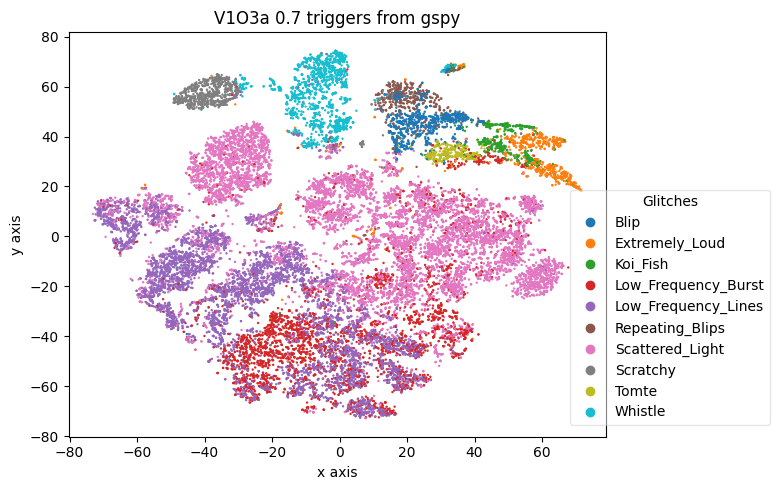

In [94]:
plt.figure(figsize=(8, 5))

cmap = plt.colormaps["tab10"]
le = LabelEncoder()
labels = le.fit_transform(labs.values.ravel())

sc = plt.scatter(proj.values[:,0], proj.values[:,1], s=0.5, c=labels, cmap=cmap)
plt.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), title="Glitches", loc='center', framealpha=0.5, markerscale=1.0, bbox_to_anchor=(1.12, 0.32))

plt.title(f'V1O3a 0.7 triggers from gspy')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.tight_layout()
plt.show()

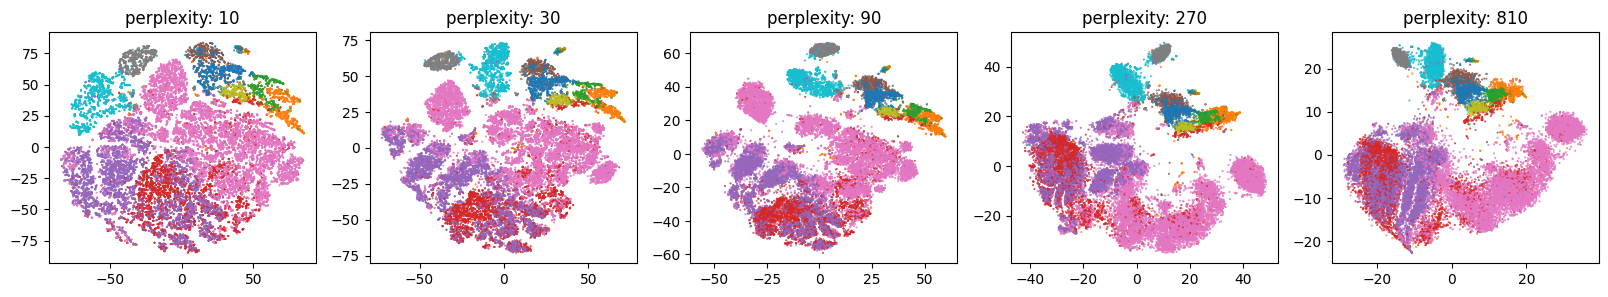

In [145]:
pxs = [10, 30, 90, 270, 810]
fig, axs = plt.subplots(1, len(pxs), figsize=(4*len(pxs), 3))

for i, p in enumerate(pxs):

    tsne = TSNE(n_components=2, perplexity=p, n_jobs=-1, learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
    proj = tsne.fit_transform(np.array(vec))

    axs[i].set_title(f'perplexity: {p}')
    axs[i].scatter(proj[:,0], proj[:,1], s=0.2, c=labels, cmap=cmap)

plt.show()

### from Francesco clusterization

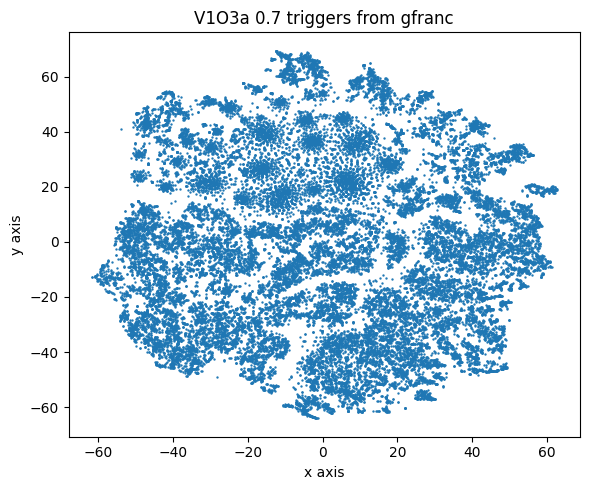

In [20]:
plt.figure(figsize=(6, 5))

sc = plt.scatter(proj.values[:,0], proj.values[:,1], s=0.5)

plt.title(f'V1O3a {tperc} triggers from {clust}')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.tight_layout()
plt.show()

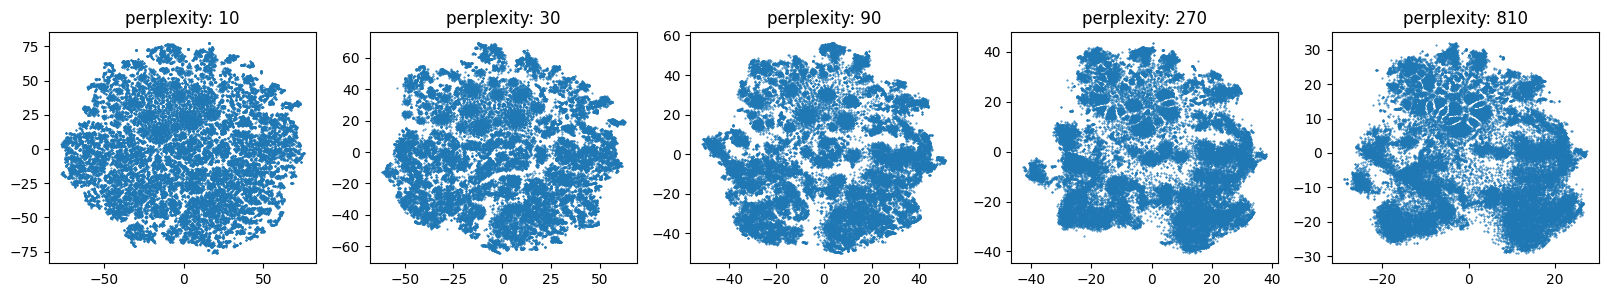

In [22]:
pxs = [10, 30, 90, 270, 810]
fig, axs = plt.subplots(1, len(pxs), figsize=(4*len(pxs), 3))

for i, p in enumerate(pxs):

    tsne = TSNE(n_components=2, perplexity=p, n_jobs=-1, learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
    proj = tsne.fit_transform(np.array(final_vecs))
    # proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])

    axs[i].set_title(f'perplexity: {p}')
    axs[i].scatter(proj[:,0], proj[:,1], s=0.2)

plt.show()

### from DetChar clusterization

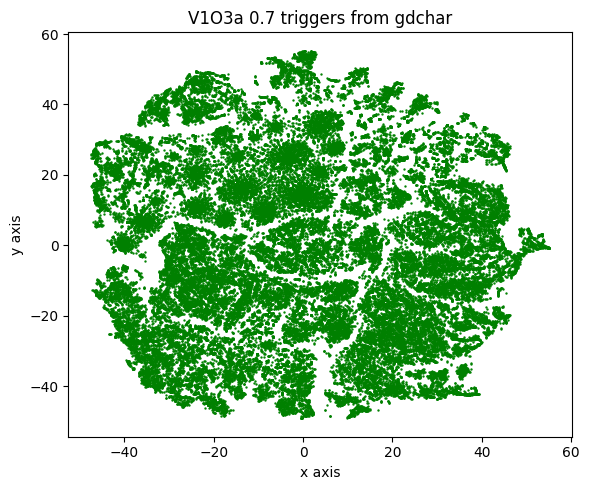

In [47]:
plt.figure(figsize=(6, 5))

sc = plt.scatter(proj.values[:,0], proj.values[:,1], s=0.5, c='green')

plt.title(f'V1O3a {tperc} triggers from {clust}')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.tight_layout()
plt.show()

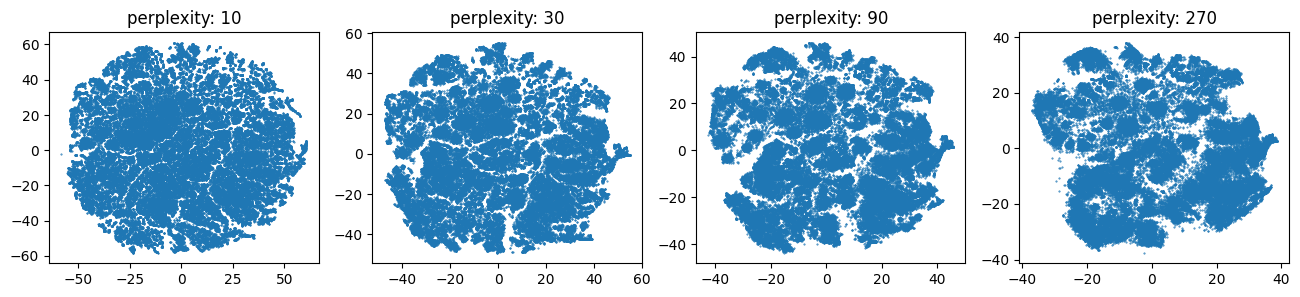

In [11]:
pxs = [10, 30, 90, 270]
fig, axs = plt.subplots(1, len(pxs), figsize=(4*len(pxs), 3))

for i, p in enumerate(pxs):

    tsne = TSNE(n_components=2, perplexity=p, n_jobs=-1, learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
    proj = tsne.fit_transform(np.array(final_vecs))
    # proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])

    axs[i].set_title(f'perplexity: {p}')
    axs[i].scatter(proj[:,0], proj[:,1], s=0.2)

plt.show()